In [19]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.stats import norm

sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [5]:
repo_folder = Path("../..")
data_folder = repo_folder / "data" / "6_CRM"
figure_folder = repo_folder / "Figures" / "6_CRM"
figure_folder.mkdir(parents=True, exist_ok=True)

In [11]:
# Get disitrbution of rates from Sulheim et al., 2025
fn = data_folder / "sulheim_2025_rates.csv"
df = pd.read_csv(fn, index_col=0)

In [113]:
df['log10(Rate [mmol/gDW/h])'] = np.log10(df['Rate [mmol/gDW/h]'])
df['log(Rate [mmol/gDW/h])'] = np.log(df['Rate [mmol/gDW/h]'])

/Users/snorre/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/snorre/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
df.columns

Index(['Metabolite', 'Carbon source', 'Rate [mmol/gDW/h]',
       'Std. Err [mmol/gDW/h]', 'Metabolite value [gDW/mmol]', 'N carbons',
       'Mol weight [g/mol]', 'Turnover [mmol/gDW/h]', 'Species', 'Dataset',
       'Metabolite id', 'Charge', 'Phosphate', 'Compound class', 'Comment',
       'Hydrogen Bond Donor Count', 'Hydrogen Bond Acceptor Count',
       'Rotatable Bond Count', 'Topological Polar Surface Area',
       'Charge (pubchem)', 'xlogP', 'pubchem id', 'Formula',
       'Molecular weight [g/mol]', 'ECMDB name', 'ECMDB ID',
       'Park et al. name', 'Thorfinnsdottir et al. abbrv',
       'Intracellular concentration [uM]', 'log10(Rate [mmol/gDW/h])',
       'log10(Metabolite value [gDW/mmol])', 'Rate [mmol C/gDW/h]',
       'Rate [g/gDW/h]', 'Metabolite value [gDW/mmol C]',
       'Metabolite value [gDW/g]', 'log10(Rate [mmol C/gDW/h])',
       'log10(Rate [g/gDW/h])', 'log10(Metabolite value [gDW/mmol C])',
       'log10(Metabolite value [gDW/g])', 'log10(Turnover [mmol/g

In [109]:
df.Dataset.unique()

array(['SINTEF-23', 'Paczia-12', 'Vila-23'], dtype=object)

In [110]:
# Drop the data from Vila et al., where there is larger uncertainty associated with the rate estimates
idx = (df.Dataset != "Vila-23")&(df['log10(Rate [mmol/gDW/h])'].notna())

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_50206/2118427411.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_50206/2118427411.py:15: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')


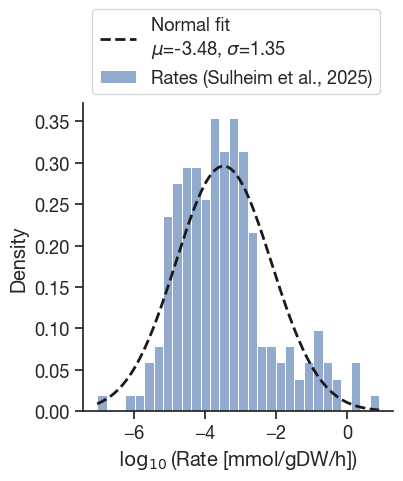

In [331]:
log10_rates = df.loc[idx, 'log10(Rate [mmol/gDW/h])'].values
rates = df.loc[idx, 'Rate [mmol/gDW/h]'].values

# Fit lognormal
mu, sigma = st.norm.fit(log10_rates)

# Plot histogram of log10(rates)
fig, ax = plt.subplots(figsize=(4,4))
l = sns.histplot(x = log10_rates, bins=30, stat='density', alpha=0.6, color='C0', edgecolor='w', label='Rates (Sulheim et al., 2025)', ax = ax)

# Plot the fitted lognormal PDF in log10 space
# This is slightly complex, because we need to do a change of variables from x to log10(x)
x = np.linspace(log10_rates.min(), log10_rates.max(), 200)
pdf = norm.pdf(x, mu, sigma)
ax.plot(x, pdf, 'k--', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={sigma:.2f}')

plt.legend()
plt.xlabel(r'$\log_{10}$(Rate [mmol/gDW/h])')
plt.ylabel('Density')
sns.move_legend(ax, "lower left", bbox_to_anchor= (0,1))
sns.despine()

plt.savefig(figure_folder / "sulheim_2025_rate_distribution.pdf", bbox_inches='tight')
plt.show()